In [33]:
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np
import pickle
import umap
import hdbscan

In [ ]:
df=pd.read_excel('../output/fen25base.xlsx')


In [3]:
df.shape

(302, 23)

In [5]:
rows_of_users= []

for i,j in df.iterrows():
    sentence  = f"An {j['Job_Seniority']} in {j['Job_Function']} from the {j['Parent Industry']} industry. Their key areas of interest include {j['aoi_1']}, {j['aoi_2']}, {j['aoi_3']}."
    rows_of_users.append(sentence)

In [6]:
len(rows_of_users)

302

In [7]:
base = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

In [8]:
embedding = base.encode(rows_of_users, normalize_embeddings=True)

In [43]:

np.save('../output/embeddingnewew.npy', embedding)

In [5]:
df=pd.read_excel('../input_data/outpt_final_cluster.xlsx')
with open("../vector/embedding_rm_new_aoi.pkl", "rb") as f:
   embeddings = pickle.load(f)


In [10]:
std= StandardScaler().fit_transform(embedding)       
std2d= umap.UMAP(n_components=2,random_state=41).fit_transform(std)


c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:

a=np.array(std2d)
std2d.shape 
np.save('../vector/feb25base.npy',std2d)

In [ ]:
clusterer = hdbscan.HDBSCAN(min_samples=11,cluster_selection_epsilon=1.5,metric="euclidean",prediction_data=True)
labels = clusterer.fit_predict(std2d)
print(np.unique(labels).max()+1)
df["cluster"] = labels

8


c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
clusterer = hdbscan.HDBSCAN(min_samples=11,cluster_selection_epsilon=1.5,metric="euclidean",prediction_data=True).fit(std2d)

In [15]:
df.to_excel('../output/fen25base.xlsx')

PermissionError: [Errno 13] Permission denied: '../output/fen25base.xlsx'

In [ ]:
top_industries = (
    df.groupby(['cluster','Parent Industry'])
      .size()
      .reset_index(name='count')
      .sort_values(['cluster', 'count'], ascending=[True, False])
      .groupby('cluster')
      .head(1)
)
# top_industries.to_excel("../output/cluster_11.xlsx")

In [89]:
top_industries


,cluster,Parent Industry,Job_Seniority,Job_Function,count
0,-1,Finance,Mid-Level,General Management,5
2,-1,Information & Technology,Junior,Consultant,3
13,0,Information & Technology,CXO,It/Technology,3
12,0,Information & Technology,CXO,Business,2
26,1,Information & Technology,Junior,It/Technology,19
38,1,Retail & Consumer,Mid-Level,General Management,7
41,2,Manufacturing,Mid-Level,General Management,19
40,2,Agriculture,Mid-Level,General Management,1
45,3,Healthcare,Mid-Level,It/Technology,11
42,3,Healthcare,Entry-Level,It/Technology,1


In [84]:
# Step 1: Melt the AOI columns into a single column
df_melted = df.melt(
    id_vars=['cluster', 'Parent Industry', 'Job_Seniority', 'Job_Function'],
    value_vars=['aoi_1', 'aoi_2', 'aoi_3'],
    var_name='aoi_type',
    value_name='aoi_value'
)
 
# Step 2: Group by relevant fields and count each AOI's frequency
aoi_counts = (
    df_melted.groupby(['cluster', 'Parent Industry', 'Job_Seniority', 'Job_Function', 'aoi_value'])
    .size()
    .reset_index(name='count')
)
 
# Step 3: Sort and select top 2 AOIs per cluster
top_2_of_cluster = (
    aoi_counts.sort_values(['cluster', 'count'], ascending=[True, False])
              .groupby('cluster')
              .head(3)
)


In [85]:
top_2_of_cluster

,cluster,Parent Industry,Job_Seniority,Job_Function,aoi_value,count
1,-1,Finance,Mid-Level,General Management,Customer Engagement,5
3,-1,Finance,Mid-Level,General Management,Artificial Intelligence,5
0,-1,Finance,Mid-Level,General Management,Automation,3
44,0,Information & Technology,CXO,Business,Customer Engagement,2
46,0,Information & Technology,CXO,Business,Artificial Intelligence,2
47,0,Information & Technology,CXO,It/Technology,Customer Engagement,2
94,1,Information & Technology,Junior,It/Technology,Customer Engagement,17
99,1,Information & Technology,Junior,It/Technology,Artificial Intelligence,16
92,1,Information & Technology,Junior,It/Technology,Automation,11
156,2,Manufacturing,Mid-Level,General Management,Artificial Intelligence,17


In [69]:
df_melted.to_excel("../output/melted.xlsx")

In [80]:
top_industries = (
    df.groupby(['cluster'])
      .size()
      .reset_index(name='count')
      .sort_values(['cluster', 'count'], ascending=[True, False])
      .groupby('cluster')
      .head()
)
# top_industries.to_excel("../output/cluster_11_count.xlsx")

In [83]:
top_industriesp = (
    df.groupby(['Parent Industry'])
      .size()
      .reset_index(name='count')
      .sort_values(['Parent Industry', 'count'], ascending=[True, False])
      .groupby('Parent Industry')
      .head()
)

In [81]:
top_industries

,cluster,count
0,-1,16
1,0,12
2,1,61
3,2,20
4,3,16
5,4,91
6,5,24
7,6,20
8,7,42


In [56]:
for eps in [0.1, 0.2, 0.5, 0.8, 1.0, 1.5, 2.0]:
    clusterer = hdbscan.HDBSCAN(
        # min_cluster_size=50,
        cluster_selection_epsilon=eps,
        min_samples=11,
        metric='euclidean'
    )
    labels = clusterer.fit_predict(std2d)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_outliers = list(labels).count(-1)
    print(f"epsilon={eps:.2f} → clusters: {n_clusters}, outliers: {n_outliers}")

epsilon=0.10 → clusters: 10, outliers: 24
epsilon=0.20 → clusters: 10, outliers: 24
epsilon=0.50 → clusters: 10, outliers: 24
epsilon=0.80 → clusters: 10, outliers: 24
epsilon=1.00 → clusters: 10, outliers: 24
epsilon=1.50 → clusters: 9, outliers: 16
epsilon=2.00 → clusters: 9, outliers: 16


c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\sklearn\ut

In [45]:
top_industries = (
    df.groupby(['aoi_2'])
      .size()
      .reset_index(name='count')
      .sort_values(['aoi_2', 'count'], ascending=[True, False])
      .groupby('aoi_2')
      .head()
)
top_industries.to_excel("../output/cluster_3aoi_2.xlsx")

[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725), (0.8666666666666667, 0.5176470588235295, 0.3215686274509804), (0.3333333333333333, 0.6588235294117647, 0.40784313725490196), (0.7686274509803922, 0.3058823529411765, 0.3215686274509804), (0.5058823529411764, 0.4470588235294118, 0.7019607843137254), (0.5764705882352941, 0.47058823529411764, 0.3764705882352941), (0.8549019607843137, 0.5450980392156862, 0.7647058823529411), (0.5490196078431373, 0.5490196078431373, 0.5490196078431373), (0.8, 0.7254901960784313, 0.4549019607843137), (0.39215686274509803, 0.7098039215686275, 0.803921568627451), (0.2980392156862745, 0.4470588235294118, 0.6901960784313725), (0.8666666666666667, 0.5176470588235295, 0.3215686274509804), (0.3333333333333333, 0.6588235294117647, 0.40784313725490196), (0.7686274509803922, 0.3058823529411765, 0.3215686274509804), (0.5058823529411764, 0.4470588235294118, 0.7019607843137254), (0.5764705882352941, 0.47058823529411764, 0.3764705882352941), (0.854901960784313

NameError: name 'ion' is not defined

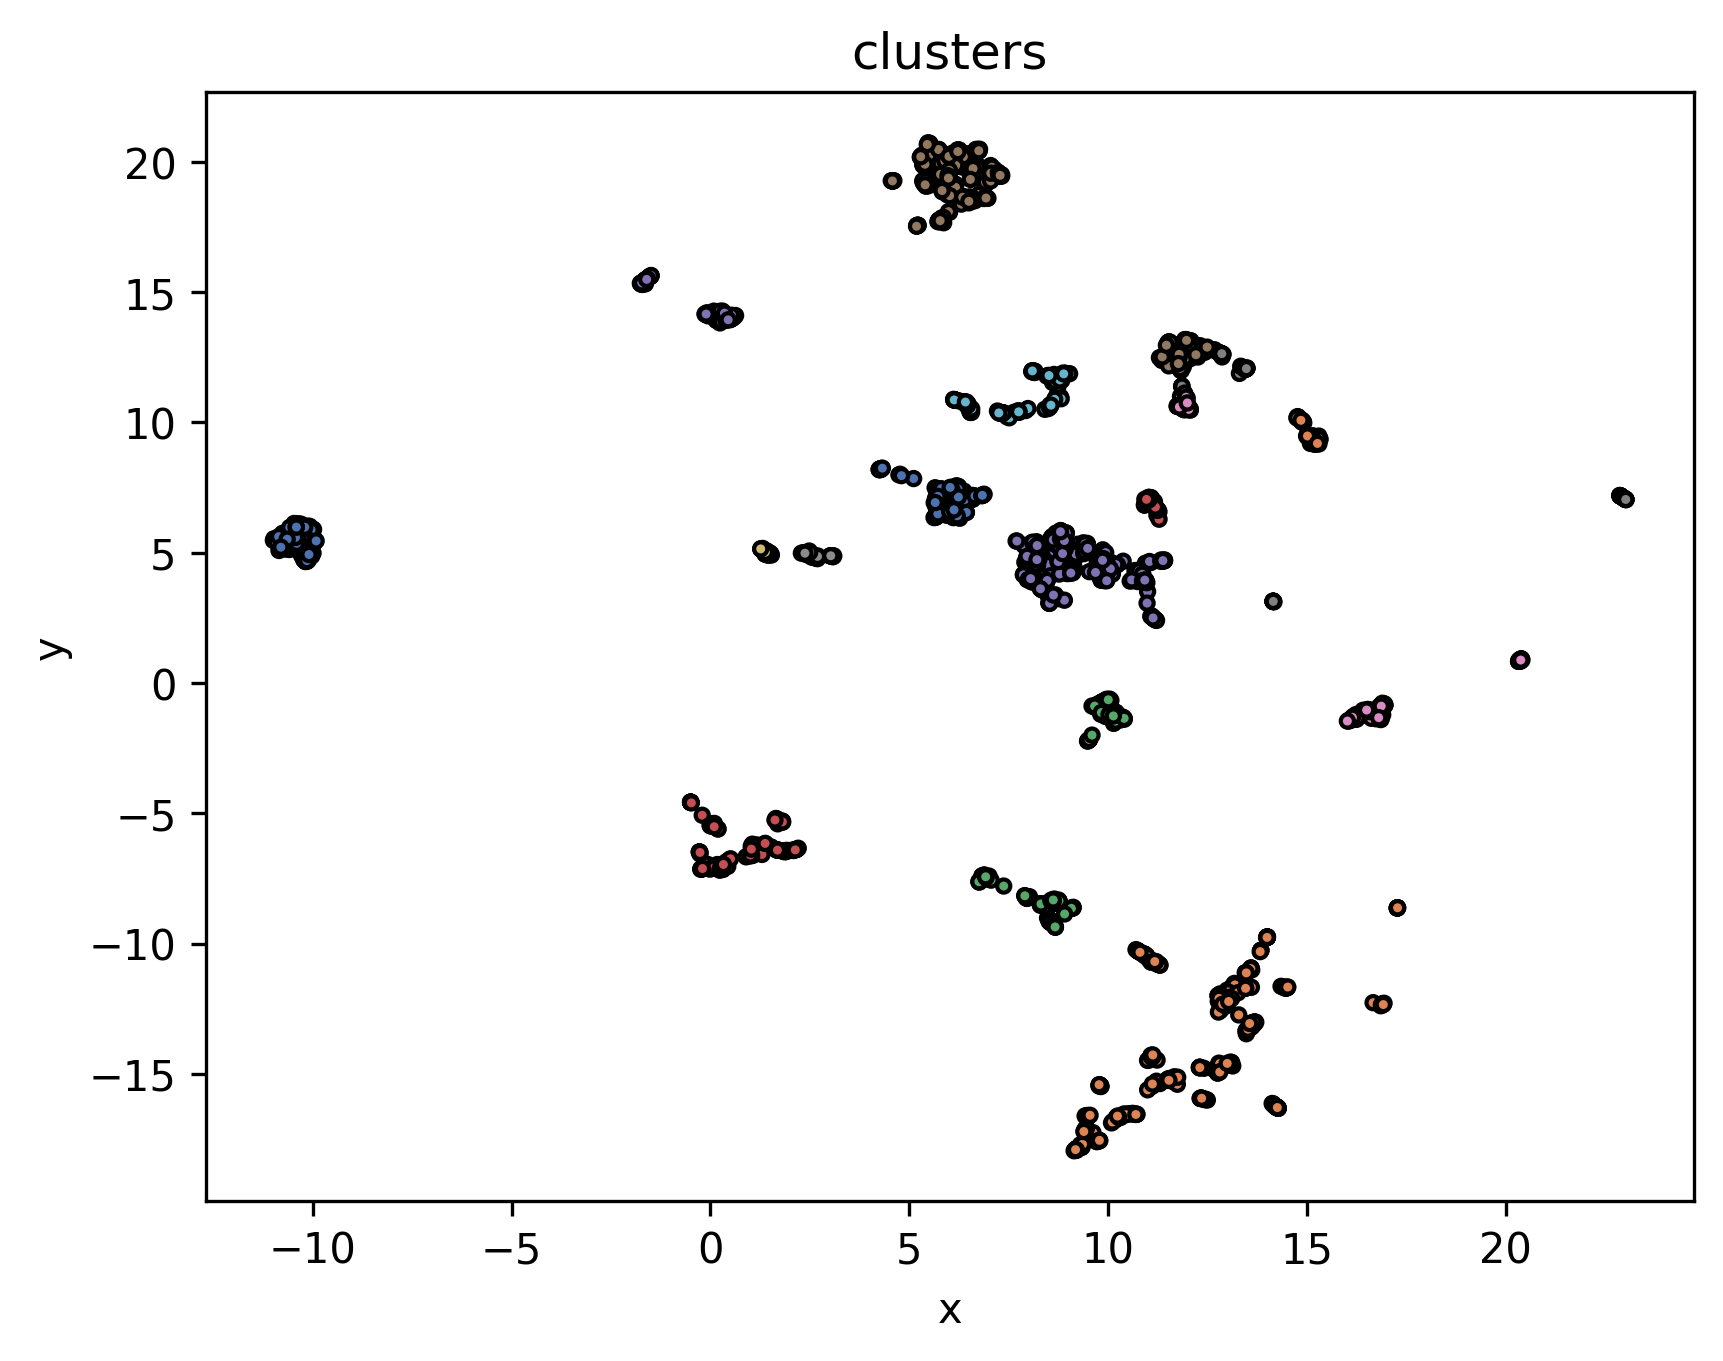

In [ ]:
#visualization 
from matplotlib import pyplot as plt
import seaborn as sb
print(pal)
pal = sb.color_palette('deep',np.unique(labels).max()+1)
colors = [pal[l] if l>=0 else(0.5,0.5,0.5) for l in labels]
print (colors)
plt.figure(dpi=300)
plt.title('clusters')
plt.xlabel('x')
plt.ylabel('y')
plt.scatter(std2d[:,0],std2d[:,1],s=10,c=colors,edgecolors='k')
plt.show()



In [ ]:
import numpy as np
import pandas as pd
import hdbscan
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import seaborn as sns

# Your data preparation



Testing different HDBSCAN parameters...


c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\sklearn\ut

Results DataFrame shape: (1881, 8)
Columns: ['cluster_selection_epsilon', 'min_samples', 'n_clusters', 'n_noise_points', 'noise_ratio', 'silhouette_score', 'calinski_harabasz_score', 'dbcv_score']

Tested 1881 parameter combinations
Top 10 parameter combinations:
     cluster_selection_epsilon  min_samples  n_clusters  n_noise_points  \
703                       0.45           11          45              54   
702                       0.45           10          44              43   
199                       0.20            2          91               6   
893                       0.55            3          41               0   
894                       0.55            4          41               0   
897                       0.55            7          40               7   
896                       0.55            6          40               7   
198                       0.20            1          92               4   
705                       0.45           13          44      

c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


ValueError: Epsilon must be a float value greater than or equal to 0!

Min samples range: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]...[61, 62, 63, 64, 65, 66, 67, 68, 69, 70]
Epsilon range: [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25]
Total combinations to test: 1750

Testing different HDBSCAN parameters...


c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\sklearn\ut


Results DataFrame shape: (1750, 8)
Columns: ['cluster_selection_epsilon', 'min_samples', 'n_clusters', 'n_noise_points', 'noise_ratio', 'silhouette_score', 'calinski_harabasz_score', 'dbcv_score']

Tested 1750 parameter combinations
Top 10 parameter combinations:
      cluster_selection_epsilon  min_samples  n_clusters  n_noise_points  \
1684                       0.25            5          76              22   
1681                       0.25            2          75               5   
1682                       0.25            3          75               8   
1471                       0.22            2          83               7   
1542                       0.23            3          83              12   
1472                       0.22            3          83              12   
1683                       0.25            4          75              12   
1685                       0.25            6          75              43   
1543                       0.23            4       

c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


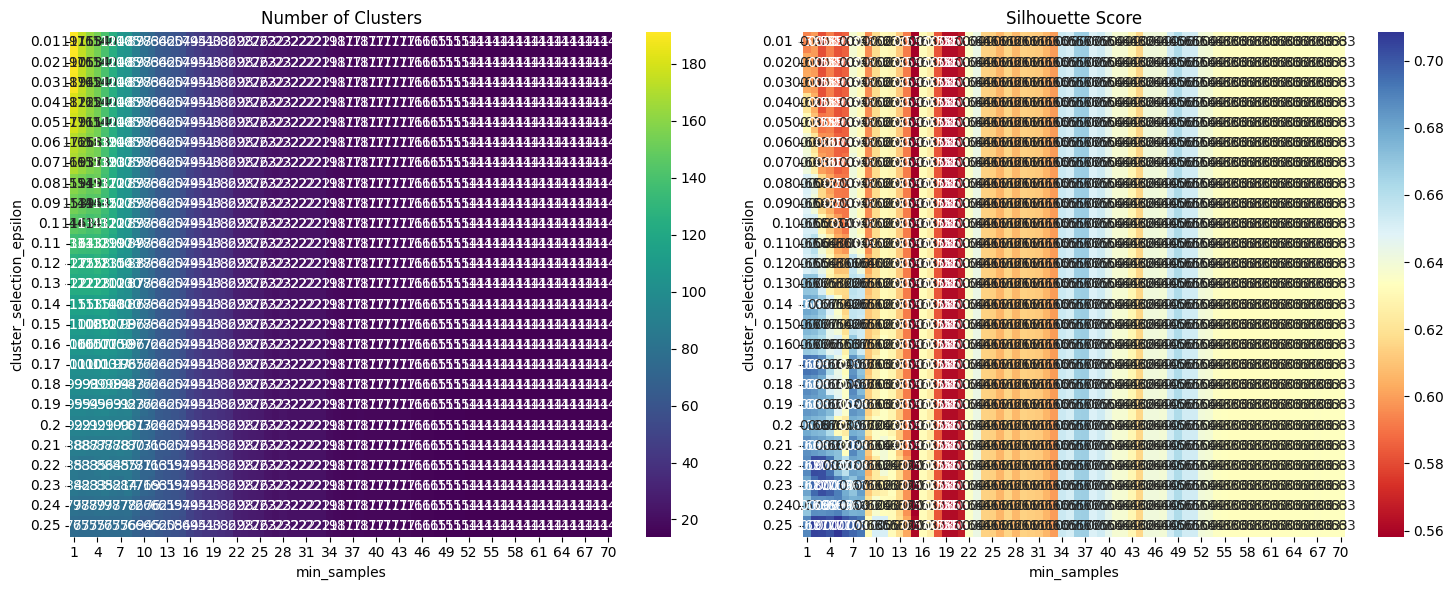


Summary of optimal parameters:
         Method  Epsilon  Min Samples  N Clusters  Noise Ratio  Silhouette
       Balanced     0.01         49.0        15.0     0.040722    0.661802
Best Silhouette     0.01         37.0        17.0     0.028128    0.667338

Exported report details to hdbscan_clustering_report.xlsx
- Sheet 1: Parameter_Combinations (1750 rows)
- Sheet 2: Optimal_Summary (2 rows)
- Sheet 3: Top_20_Results (20 rows)


In [26]:


# Your data preparation
std2d1 = np.array(std2d)

def evaluate_hdbscan_parameters(data, min_samples_list, epsilon_range):
    """
    Evaluate HDBSCAN with different parameter combinations (focusing on min_samples and cluster_selection_epsilon)
    """
    results = []
    
    for epsilon in epsilon_range:
        for min_samples in min_samples_list:
            try:
                # Convert epsilon to Python float to avoid type issues
                epsilon_float = float(epsilon)
                
                # Validate epsilon
                if epsilon_float < 0:
                    print(f"Skipping negative epsilon: {epsilon_float}")
                    continue
                
                # Fit HDBSCAN with metric='euclidean' (min_cluster_size will use default)
                clusterer = hdbscan.HDBSCAN(
                    min_samples=min_samples,
                    metric='euclidean',
                    cluster_selection_epsilon=epsilon_float
                )
                labels = clusterer.fit_predict(data)
                
                # Calculate metrics
                n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
                n_noise = list(labels).count(-1)
                noise_ratio = n_noise / len(labels)
                
                # Silhouette score (only if we have clusters)
                silhouette = -1
                if n_clusters > 1:
                    try:
                        silhouette = silhouette_score(data, labels)
                    except:
                        silhouette = -1
                
                # Calinski-Harabasz score
                ch_score = -1
                if n_clusters > 1:
                    try:
                        ch_score = calinski_harabasz_score(data, labels)
                    except:
                        ch_score = -1
                
                # DBCV score (HDBSCAN's internal metric)
                dbcv_score = -1
                if hasattr(clusterer, 'relative_validity_'):
                    dbcv_score = clusterer.relative_validity_
                
                results.append({
                    'cluster_selection_epsilon': epsilon_float,
                    'min_samples': min_samples,
                    'n_clusters': n_clusters,
                    'n_noise_points': n_noise,
                    'noise_ratio': noise_ratio,
                    'silhouette_score': silhouette,
                    'calinski_harabasz_score': ch_score,
                    'dbcv_score': dbcv_score
                })
                
            except Exception as e:
                print(f"Error with params: epsilon={epsilon}, min_samples={min_samples}: {str(e)}")
                continue
    
    return pd.DataFrame(results)

def find_optimal_parameters(results_df, criteria='balanced'):
    """
    Find optimal parameters based on different criteria with better validation
    """
    # Check if DataFrame is empty or missing required columns
    if results_df.empty:
        print("Results DataFrame is empty!")
        return None
        
    if 'silhouette_score' not in results_df.columns:
        print(f"Missing silhouette_score column. Available columns: {list(results_df.columns)}")
        return None
    
    # Additional validation for epsilon values
    valid_epsilon = results_df['cluster_selection_epsilon'].notna() & (results_df['cluster_selection_epsilon'] >= 0)
    
    # Filter out results with no clusters or too many noise points
    filtered_df = results_df[
        (results_df['n_clusters'] > 0) & 
        (results_df['n_clusters'] < 20) &  # Avoid too many clusters
        (results_df['noise_ratio'] < 0.5) &  # Avoid too much noise
        (results_df['silhouette_score'] > -1) &  # Valid silhouette scores
        valid_epsilon  # Valid epsilon values
    ].copy()
    
    if len(filtered_df) == 0:
        print("No suitable parameter combinations found after filtering!")
        print("Trying with relaxed criteria...")
        
        # Try with more relaxed criteria
        relaxed_df = results_df[
            (results_df['n_clusters'] > 0) & 
            (results_df['silhouette_score'] > -1) &
            valid_epsilon
        ].copy()
        
        if len(relaxed_df) > 0:
            filtered_df = relaxed_df
        else:
            # Last resort - just get valid epsilon values
            valid_rows = results_df[valid_epsilon]
            if len(valid_rows) > 0:
                return valid_rows.iloc[0]
            else:
                print("No valid epsilon values found!")
                return None
    
    if criteria == 'silhouette':
        # Best silhouette score
        optimal = filtered_df.loc[filtered_df['silhouette_score'].idxmax()]
        
    elif criteria == 'dbcv':
        # Best DBCV score (HDBSCAN's preferred metric)
        valid_dbcv = filtered_df[filtered_df['dbcv_score'] > -1]
        if len(valid_dbcv) > 0:
            optimal = valid_dbcv.loc[valid_dbcv['dbcv_score'].idxmax()]
        else:
            optimal = filtered_df.loc[filtered_df['silhouette_score'].idxmax()]
            
    elif criteria == 'balanced':
        # Balanced approach: good silhouette, reasonable cluster count, low noise
        filtered_df['composite_score'] = (
            filtered_df['silhouette_score'] * 0.4 +
            (1 - filtered_df['noise_ratio']) * 0.3 +
            (1 / (1 + abs(filtered_df['n_clusters'] - 8))) * 0.3  # Prefer ~8 clusters
        )
        optimal = filtered_df.loc[filtered_df['composite_score'].idxmax()]
        
    elif criteria == 'minimal_noise':
        # Minimize noise points
        min_noise = filtered_df.loc[filtered_df['noise_ratio'].idxmin()]
        # Among minimal noise, pick best silhouette
        min_noise_df = filtered_df[filtered_df['noise_ratio'] == min_noise['noise_ratio']]
        optimal = min_noise_df.loc[min_noise_df['silhouette_score'].idxmax()]
    
    return optimal

def apply_optimal_clustering(data, optimal_params):
    """
    Apply the optimal clustering parameters with proper validation
    """
    if optimal_params is None:
        print("No optimal parameters found!")
        return None, None
    
    # Debug the epsilon value
    epsilon_value = optimal_params['cluster_selection_epsilon']
    print(f"Debug - Original epsilon value: {epsilon_value}")
    print(f"Debug - Epsilon type: {type(epsilon_value)}")
    print(f"Debug - Is NaN: {pd.isna(epsilon_value)}")
    
    # Validate and convert epsilon
    try:
        if pd.isna(epsilon_value):
            print("Warning: Epsilon is NaN, setting to 0.0")
            epsilon_float = 0.0
        else:
            epsilon_float = float(epsilon_value)
            if epsilon_float < 0:
                print(f"Warning: Epsilon is negative ({epsilon_float}), setting to 0.0")
                epsilon_float = 0.0
    except (ValueError, TypeError):
        print(f"Error converting epsilon to float: {epsilon_value}, setting to 0.0")
        epsilon_float = 0.0
    
    print(f"Debug - Final epsilon value: {epsilon_float}")
    
    # Validate min_samples
    try:
        min_samples_int = int(optimal_params['min_samples'])
        if min_samples_int < 1:
            min_samples_int = 1
    except (ValueError, TypeError):
        print("Error with min_samples, setting to 1")
        min_samples_int = 1
    
    try:
        clusterer = hdbscan.HDBSCAN(
            min_samples=min_samples_int,
            metric='euclidean',
            cluster_selection_epsilon=epsilon_float
        )
        
        labels = clusterer.fit_predict(data)
        
        print(f"Applied clustering with:")
        print(f"- cluster_selection_epsilon: {epsilon_float}")
        print(f"- min_samples: {min_samples_int}")
        print(f"Results:")
        print(f"- Number of clusters: {optimal_params['n_clusters']}")
        print(f"- Noise points: {optimal_params['n_noise_points']}")
        print(f"- Silhouette score: {optimal_params['silhouette_score']:.3f}")
        
        return labels, clusterer
        
    except Exception as e:
        print(f"Error in HDBSCAN clustering: {str(e)}")
        return None, None

def plot_parameter_results(results_df):
    """
    Create heatmaps showing clustering results for different parameters
    """
    if results_df.empty:
        print("No data to plot!")
        return
        
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    try:
        # Number of clusters heatmap
        pivot_clusters = results_df.pivot_table(
            values='n_clusters', 
            index='cluster_selection_epsilon', 
            columns='min_samples'
        )
        
        # Silhouette score heatmap
        pivot_silhouette = results_df.pivot_table(
            values='silhouette_score', 
            index='cluster_selection_epsilon', 
            columns='min_samples'
        )
        
        sns.heatmap(pivot_clusters, annot=True, fmt='.0f', 
                    ax=axes[0], cmap='viridis')
        axes[0].set_title('Number of Clusters')
        
        sns.heatmap(pivot_silhouette, annot=True, fmt='.2f', 
                    ax=axes[1], cmap='RdYlBu')
        axes[1].set_title('Silhouette Score')
        
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error creating plots: {str(e)}")

# Define parameter ranges to test
min_samples_list = [l for l in range(1, 71)]
# Convert epsilon range to regular Python floats and round to avoid precision issues
epsilon_range = [round(float(x), 2) for x in np.arange(0.01, 0.26, 0.01)]

# Print ranges for verification
print(f"Min samples range: {min_samples_list[:10]}...{min_samples_list[-10:]}")
print(f"Epsilon range: {epsilon_range}")
print(f"Total combinations to test: {len(min_samples_list) * len(epsilon_range)}")

# Evaluate all parameter combinations
print("\nTesting different HDBSCAN parameters...")
results_df = evaluate_hdbscan_parameters(std2d1, min_samples_list, epsilon_range)

# Check if results_df is properly created
print(f"\nResults DataFrame shape: {results_df.shape}")
print(f"Columns: {list(results_df.columns)}")

if not results_df.empty:
    # Display results sorted by silhouette score
    print(f"\nTested {len(results_df)} parameter combinations")
    valid_results = results_df[results_df['silhouette_score'] > -1]
    if not valid_results.empty:
        print("Top 10 parameter combinations:")
        print(valid_results.sort_values('silhouette_score', ascending=False).head(10))
    else:
        print("No valid silhouette scores found!")
        print("Sample results:")
        print(results_df.head())

    # Find optimal parameters using different criteria
    optimal_balanced = find_optimal_parameters(results_df, 'balanced')
    optimal_silhouette = find_optimal_parameters(results_df, 'silhouette')
    optimal_dbcv = find_optimal_parameters(results_df, 'dbcv')

    if optimal_balanced is not None and optimal_silhouette is not None:
        print("\n" + "="*60)
        print("OPTIMAL PARAMETERS COMPARISON:")
        print("="*60)

        print("\nOptimal Parameters (Balanced approach):")
        print(f"- Epsilon: {optimal_balanced['cluster_selection_epsilon']}")
        print(f"- Min samples: {optimal_balanced['min_samples']}")
        print(f"- Number of clusters: {optimal_balanced['n_clusters']}")
        print(f"- Noise ratio: {optimal_balanced['noise_ratio']:.2f}")
        print(f"- Silhouette score: {optimal_balanced['silhouette_score']:.3f}")

        print("\nOptimal Parameters (Best Silhouette):")
        print(f"- Epsilon: {optimal_silhouette['cluster_selection_epsilon']}")
        print(f"- Min samples: {optimal_silhouette['min_samples']}")
        print(f"- Number of clusters: {optimal_silhouette['n_clusters']}")
        print(f"- Noise ratio: {optimal_silhouette['noise_ratio']:.2f}")
        print(f"- Silhouette score: {optimal_silhouette['silhouette_score']:.3f}")

        # Apply optimal clustering (using balanced criteria)
        print("\n" + "="*60)
        print("APPLYING OPTIMAL CLUSTERING:")
        print("="*60)
        optimal_labels, optimal_clusterer = apply_optimal_clustering(std2d1, optimal_balanced)

        if optimal_labels is not None:
            # Add to your dataframe
            df["cluster_2d_optimal"] = optimal_labels

            # Visualize parameter search results
            plot_parameter_results(results_df)

            # Create a summary dataframe for easy comparison
            summary_df = pd.DataFrame([
                {
                    'Method': 'Balanced',
                    'Epsilon': optimal_balanced['cluster_selection_epsilon'],
                    'Min Samples': optimal_balanced['min_samples'],
                    'N Clusters': optimal_balanced['n_clusters'],
                    'Noise Ratio': optimal_balanced['noise_ratio'],
                    'Silhouette': optimal_balanced['silhouette_score']
                },
                {
                    'Method': 'Best Silhouette',
                    'Epsilon': optimal_silhouette['cluster_selection_epsilon'],
                    'Min Samples': optimal_silhouette['min_samples'],
                    'N Clusters': optimal_silhouette['n_clusters'],
                    'Noise Ratio': optimal_silhouette['noise_ratio'],
                    'Silhouette': optimal_silhouette['silhouette_score']
                }
            ])

            print("\nSummary of optimal parameters:")
            print(summary_df.to_string(index=False))

            # Function to export report details to Excel
            def export_to_excel(results_df, summary_df, filename='hdbscan_clustering_report.xlsx'):
                try:
                    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
                        results_df.to_excel(writer, sheet_name='Parameter_Combinations', index=False)
                        summary_df.to_excel(writer, sheet_name='Optimal_Summary', index=False)
                        
                        # Additional sheet with top results
                        top_results = results_df[results_df['silhouette_score'] > -1].sort_values(
                            'silhouette_score', ascending=False).head(20)
                        top_results.to_excel(writer, sheet_name='Top_20_Results', index=False)
                        
                    print(f"\nExported report details to {filename}")
                    print(f"- Sheet 1: Parameter_Combinations ({len(results_df)} rows)")
                    print(f"- Sheet 2: Optimal_Summary ({len(summary_df)} rows)")
                    print(f"- Sheet 3: Top_20_Results (20 rows)")
                    
                except Exception as e:
                    print(f"Error exporting to Excel: {str(e)}")

            # Perform the export
            export_to_excel(results_df, summary_df)
        else:
            print("Failed to apply optimal clustering!")
    else:
        print("Failed to find optimal parameters!")
        if optimal_balanced is None:
            print("- No balanced optimal parameters found")
        if optimal_silhouette is None:
            print("- No silhouette optimal parameters found")
else:
    print("No results generated! Check your data and parameters.")
    print("Possible issues:")
    print("- std2d is not defined or empty")
    print("- Data format is incorrect")
    print("- Parameter ranges are invalid")


In [49]:
print(std2d)
a=[[1,2],[3,4]]
print([a[:,0]])

[[  6.3700976    7.003527  ]
 [  0.51817954  14.036977  ]
 [  3.0663378    4.875859  ]
 ...
 [ 16.923807   -12.340899  ]
 [  7.285971    19.48457   ]
 [  8.564889    10.662851  ]]


TypeError: list indices must be integers or slices, not tuple